In [1]:
!uv pip install SimpleITK monai gdown

Using Python 3.12.13 environment at: /usr
Resolved 42 packages in 362ms
Prepared 2 packages in 1m 12s
Installed 2 packages in 9ms
 + monai==1.6.0
 + simpleitk==2.5.6


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
import os
import glob
import zipfile
import random
from pathlib import Path
import torch
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning, message=".*non-tuple sequence for multidimensional indexing.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*cuda.cudart module is deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*monai.transforms.*")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Load MSSEG dataset

In [4]:
MSSEG_TRAIN_ZIP = "/content/drive/MyDrive/MSSEG-Training.zip"
MSSEG_TEST_ZIP = "/content/drive/MyDrive/MSSEG-Testing.zip"
MSSEG_EXTRACT_DIR = "MSSEG-Training"
MSSEG_EXTRACT_DIR_TEST = "MSSEG-Testing"

def unzip_if_needed(zip_path, extract_dir):
    if zip_path and os.path.exists(zip_path):
        marker = Path(extract_dir) / ".extracted"
        if not marker.exists():
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)
            marker.touch()
        return extract_dir
    return extract_dir

def first_match(files, include_terms, exclude_terms=(), path_must_include=None):
    include_terms = [t.upper() for t in include_terms]
    exclude_terms = [t.upper() for t in exclude_terms]
    candidates = []
    for f in files:
        name = os.path.basename(f).upper()
        full_path_upper = f.upper()
        if path_must_include and path_must_include.upper() not in full_path_upper:
            continue
        if all(t in name for t in include_terms) and not any(t in name for t in exclude_terms):
            candidates.append(f)
    return sorted(candidates)[0] if candidates else None

def find_case_files(nii_files, case_log_id="Unknown Case"):
    if not nii_files:
        print(f"  [Warning] No NIfTI files found at all for {case_log_id}")
        return None

    flair = first_match(nii_files, ["FLAIR"], path_must_include="PREPROCESSED_DATA")
    t2 = first_match(nii_files, ["T2"], exclude_terms=["T2STAR", "T2_STAR"], path_must_include="PREPROCESSED_DATA")

    t1_exclude = ["GADO", "GD", "GAD", "CONTRAST", "FLAIR", "T2", "CONSENSUS", "MASK", "SEG", "GT"]
    t1 = first_match(nii_files, ["T1"], t1_exclude, path_must_include="PREPROCESSED_DATA")

    if not t1:
        dp_fallback = first_match(nii_files, ["DP"], t1_exclude, path_must_include="PREPROCESSED_DATA")
        if dp_fallback:
            print(f"  [CRITICAL WARNING] T1 is missing for {case_log_id}, and DP scan was found. Skipping case to avoid Channel Corruption!")

    label = (first_match(nii_files, ["CONSENSUS"]) or first_match(nii_files, ["LESION"]) or first_match(nii_files, ["GT"]))

    if not (flair and t1 and t2 and label):
        missing = []
        if not flair: missing.append("FLAIR")
        if not t1: missing.append("T1")
        if not t2: missing.append("T2")
        if not label: missing.append("LABEL/CONSENSUS")
        print(f"  [Dropped Case] {case_log_id} is missing modalities: {missing}")
        return None

    return {"flair": flair, "t1": t1, "t2": t2, "label": label}

def collect_dataset(root_dir, source_name):
    root_dir = str(root_dir)
    if not os.path.exists(root_dir): return []
    patient_map = {}

    for root, dirs, files in os.walk(root_dir):
        nii_in_dir = [os.path.join(root, f) for f in files if f.lower().endswith(('.nii', '.nii.gz'))]
        if not nii_in_dir: continue

        parts = Path(root).parts
        patient_folder = next((p for p in parts if "PATIENT_" in p.upper()), None)

        if patient_folder:
            idx = parts.index(patient_folder)
            center_folder = parts[idx-1] if idx > 0 else "Center_Unknown"
            key = f"{center_folder}_{patient_folder}"
            if key not in patient_map: patient_map[key] = []
            patient_map[key].extend(nii_in_dir)

    final_cases = []
    for key, all_files in patient_map.items():
        case_log_id = f"{source_name}_{key}"
        item = find_case_files(all_files, case_log_id=case_log_id)
        if item:
            item["source"] = source_name
            item["case_id"] = case_log_id
            final_cases.append(item)

    return sorted(final_cases, key=lambda x: x['case_id'])

msseg_root = unzip_if_needed(MSSEG_TRAIN_ZIP, MSSEG_EXTRACT_DIR)
msseg_test_root = unzip_if_needed(MSSEG_TEST_ZIP, MSSEG_EXTRACT_DIR_TEST)

msseg_train_files = collect_dataset(msseg_root, "MSSEG_TRAIN")
msseg_test_files = collect_dataset(msseg_test_root, "MSSEG_TEST")

print(f"MSSEG train cases found: {len(msseg_train_files)}")
print(f"MSSEG test cases found: {len(msseg_test_files)}")

MSSEG train cases found: 15
MSSEG test cases found: 38


## Data Preprocessing & SplitSplit

In [5]:
from sklearn.model_selection import train_test_split
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, ConcatItemsd, DeleteItemsd,
    RandCropByPosNegLabeld, EnsureTyped, CropForegroundd,
    RandFlipd, RandRotate90d, RandScaleIntensityd, RandShiftIntensityd,
    RandGaussianNoised, RandBiasFieldd, RandAdjustContrastd, Lambdad,
)
from monai.data import PersistentDataset, DataLoader
import os
import random

def binarize_label(x):
    return (x > 0).astype(x.dtype)

base_transforms = [
    LoadImaged(keys=["flair", "t1", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
    Orientationd(keys=["flair", "t1", "t2", "label"], axcodes="RAS"),
    Spacingd(
        keys=["flair", "t1", "t2", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "bilinear", "bilinear", "nearest"),
        padding_mode="zeros",
    ),
    Lambdad(keys="label", func=binarize_label),
    CropForegroundd(keys=["flair", "t1", "t2", "label"], source_key="flair"),
    NormalizeIntensityd(keys=["flair", "t1", "t2"], nonzero=True, channel_wise=True),
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
    DeleteItemsd(keys=["flair", "t1", "t2"]),
]

num_samples_per_image = 6
train_transforms = Compose(base_transforms + [
    RandCropByPosNegLabeld(
        keys=["image", "label"], label_key="label",
        spatial_size=(96, 96, 96), pos=5, neg=1,
        num_samples=num_samples_per_image, image_key="image", image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.25, max_k=3),
    RandScaleIntensityd(keys="image", factors=0.2, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.15, prob=0.5),
    RandGaussianNoised(keys="image", prob=0.15, mean=0.0, std=0.01),
    RandBiasFieldd(keys="image", prob=0.15, coeff_range=(0.0, 0.03)),
    RandAdjustContrastd(keys="image", prob=0.2, gamma=(0.8, 1.2)),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])
test_transforms = Compose(base_transforms + [EnsureTyped(keys=["image", "label"])])

# Randomly choose 12 Train and 3 Val from the 15 train files
shuffled_files = random.sample(msseg_train_files, len(msseg_train_files))
train_files = shuffled_files[:12]
val_files = shuffled_files[12:15]
test_files = msseg_test_files

print(f"--- Dataset Statistics ---")
print(f"Initial volumes for Train: {len(train_files)}")
print(f"Initial volumes for Val: {len(val_files)}")
print(f"Initial volumes for Test: {len(test_files)}")

cache_dir_train = "/content/persistent_cache_train"
cache_dir_val = "/content/persistent_cache_val"
cache_dir_test = "/content/persistent_cache_test"

os.makedirs(cache_dir_train, exist_ok=True)
os.makedirs(cache_dir_val, exist_ok=True)
os.makedirs(cache_dir_test, exist_ok=True)

train_ds = PersistentDataset(data=train_files, transform=train_transforms, cache_dir=cache_dir_train)
val_ds = PersistentDataset(data=val_files, transform=val_transforms, cache_dir=cache_dir_val)
test_ds = PersistentDataset(data=test_files, transform=test_transforms, cache_dir=cache_dir_test)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

--- Dataset Statistics ---
Initial volumes for Train: 12
Initial volumes for Val: 3
Initial volumes for Test: 38


## Data Analysis

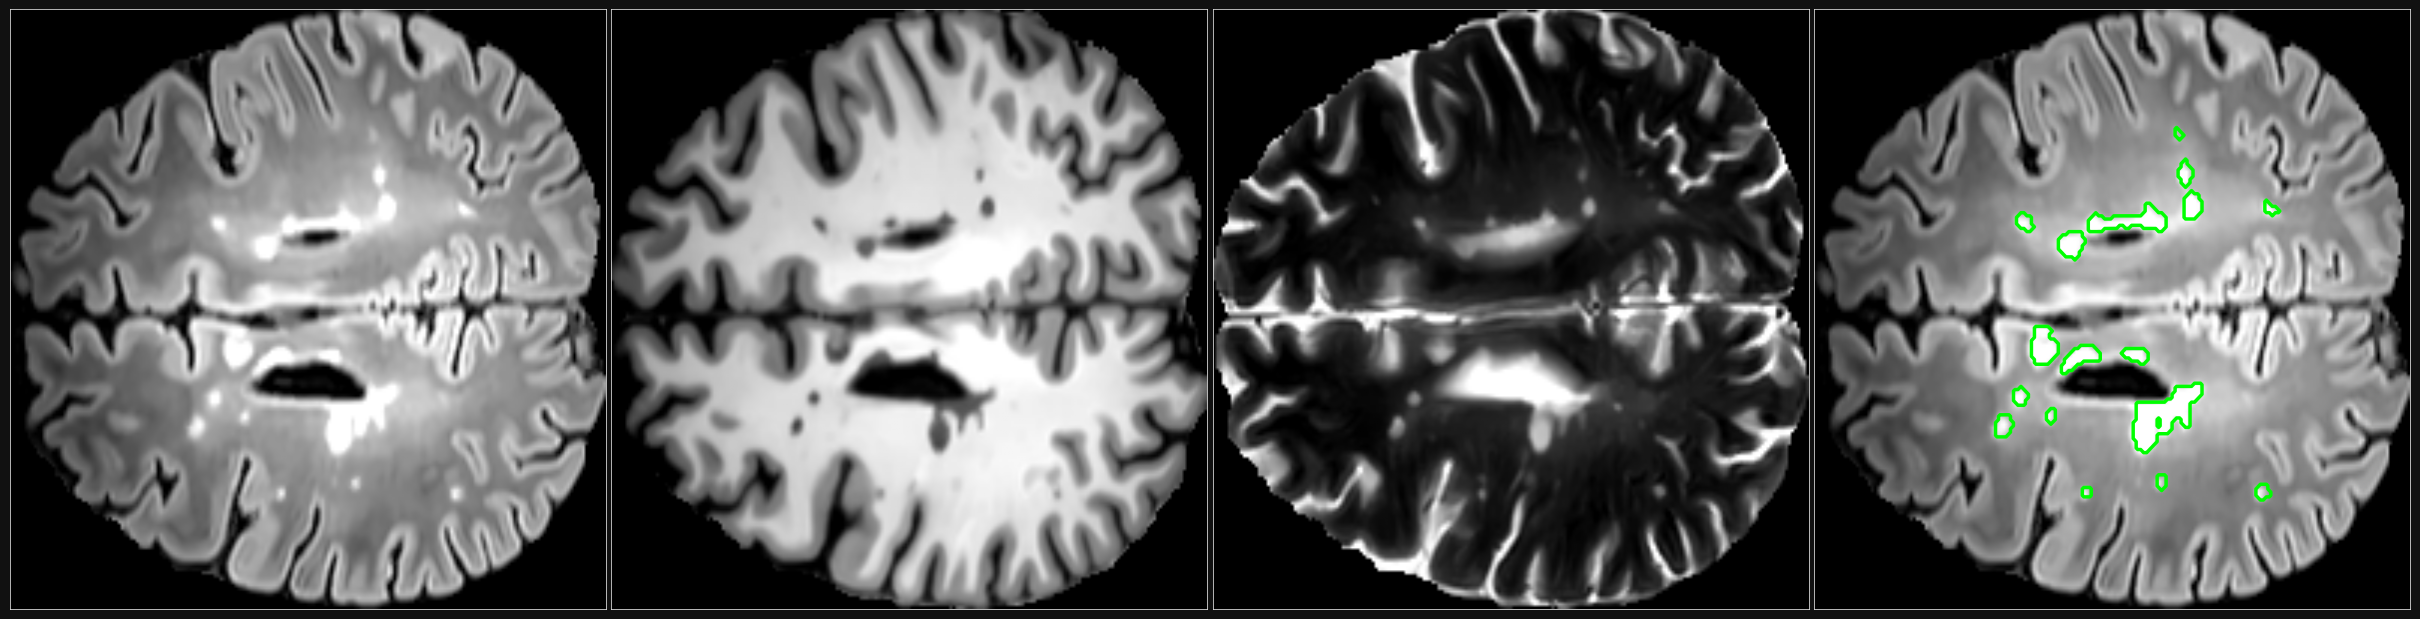

In [6]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

def normalize_image(img):
    img = img.astype(np.float32)
    mask = img > 0
    if np.any(mask):
        low = np.percentile(img[mask], 2)
        high = np.percentile(img[mask], 98)
        img = np.clip(img, low, high)
        img = (img - low) / (high - low + 1e-8)
    return img

def crop_brain(img, margin=0):
    mask = img > 0
    if not np.any(mask): return img, (0, img.shape[0], 0, img.shape[1])
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    y0, x0 = max(y0 - margin, 0), max(x0 - margin, 0)
    y1, x1 = min(y1 + margin, img.shape[0]), min(x1 + margin, img.shape[1])
    return img[y0:y1, x0:x1], (y0, y1, x0, x1)

def visualize_sample(sample_dict, slice_idx=None):
    data = {k: nib.load(sample_dict[k]).get_fdata() for k in ["flair", "t1", "t2", "label"]}
    if slice_idx is None:
        lesion_area = data["label"].sum(axis=(0, 1))
        slice_idx = np.argmax(lesion_area) if lesion_area.max() > 0 else data["label"].shape[2] // 2

    slices = {k: data[k][:, :, slice_idx] for k in data}
    for k in ["flair", "t1", "t2"]: slices[k] = normalize_image(slices[k])
    _, bbox = crop_brain(slices["flair"])
    y0, y1, x0, x1 = bbox
    for k in slices: slices[k] = slices[k][y0:y1, x0:x1]

    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=100, facecolor='#111111')

    panels = [
        (slices["flair"], "gray", None),
        (slices["t1"], "gray", None),
        (slices["t2"], "gray", None),
        (slices["flair"], "gray", slices["label"])
    ]

    for i, (img, cmap, lbl) in enumerate(panels):
        ax = axes[i]
        ax.imshow(img, cmap=cmap, aspect='auto', interpolation='bilinear', origin='lower')

        if lbl is not None:
            ax.contour(lbl, levels=[0.5], colors='lime', linewidths=2.5, origin='lower')

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('white')
            spine.set_linewidth(0.5)

        ax.set_xticks([])
        ax.set_yticks([])

    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0.01)
    plt.show()

if 'train_files' in globals() and train_files:
    visualize_sample(train_files[0])

## Model Architecture (Tri-Encoder with Deep Supervision)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class ConvBlock3D(nn.Module):
    def __init__(self, input_channels, output_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv3d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout3d(p=dropout)) # fix overfitting
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class AttentionGate3D(nn.Module):
    def __init__(self, gating_channels, skip_channels, intermediate_channels):
        super().__init__()
        self.W_gating = nn.Sequential(
            nn.Conv3d(gating_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.W_skip = nn.Sequential(
            nn.Conv3d(skip_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.attention_filter = nn.Sequential(
            nn.Conv3d(intermediate_channels, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.relu = nn.LeakyReLU(0.01, inplace=True)

    def forward(self, gating_signal, skip_connection):
        relevance_map = self.relu(self.W_gating(gating_signal) + self.W_skip(skip_connection))
        attention_coefficients = self.attention_filter(relevance_map)
        gated_skip = skip_connection * attention_coefficients
        # NOVELTY (explainability): return the raw coefficient map too, instead of discarding it
        return gated_skip, attention_coefficients


class ModalityGate3D(nn.Module):
    """
    NOVELTY (modality-adaptive fusion): SE-style gate that learns per-sample,
    per-modality reliability weights instead of trusting FLAIR/T1/T2 equally
    via plain concatenation. Softmax over modalities -> each branch's features
    are rescaled by how much the network currently trusts that modality.
    """
    def __init__(self, num_modalities, channels_per_modality, reduction=4):
        super().__init__()
        total_channels = num_modalities * channels_per_modality
        self.num_modalities = num_modalities
        self.pool = nn.AdaptiveAvgPool3d(1)
        hidden = max(total_channels // reduction, num_modalities)
        self.mlp = nn.Sequential(
            nn.Linear(total_channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_modalities),
        )
        self.softmax = nn.Softmax(dim=1)

    def forward(self, modality_features):
        # modality_features: list of [B, C, D, H, W] tensors, one per modality
        b = modality_features[0].shape[0]
        stacked = torch.cat(modality_features, dim=1)
        pooled = self.pool(stacked).view(b, -1)
        weights = self.softmax(self.mlp(pooled))  # [B, num_modalities]

        gated = []
        for i, feat in enumerate(modality_features):
            w = weights[:, i].view(b, 1, 1, 1, 1)
            gated.append(feat * w)
        return gated, weights


class TriEncoderAttentionUNet3D(nn.Module):
    def __init__(self, dropout=0.25, modality_dropout_p=0.15):
        super().__init__()
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)
        self.modality_dropout_p = modality_dropout_p  # NOVELTY (robustness)

        self.flair_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t1_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t2_l1 = ConvBlock3D(1, 16, dropout=0.0)

        self.flair_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t1_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t2_level_2 = ConvBlock3D(16, 32, dropout=dropout)

        # NOVELTY: modality-adaptive gates before fusion, one per resolution level
        self.modality_gate_l1 = ModalityGate3D(num_modalities=3, channels_per_modality=16)
        self.modality_gate_l2 = ModalityGate3D(num_modalities=3, channels_per_modality=32)

        self.fuse_l1 = ConvBlock3D(48, 32, dropout=dropout)
        self.fuse_level_2 = ConvBlock3D(96, 64, dropout=dropout)
        self.joint_l3 = ConvBlock3D(64, 128, dropout=dropout)

        self.bottleneck = ConvBlock3D(128, 256, dropout=dropout * 2)

        self.up3 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionGate3D(128, 128, 64)
        self.dec3 = ConvBlock3D(256, 128, dropout=dropout)

        self.up2 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionGate3D(64, 64, 32)
        self.dec2 = ConvBlock3D(128, 64, dropout=dropout)

        self.up1 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.att1 = AttentionGate3D(32, 32, 16)
        self.dec1 = ConvBlock3D(64, 32, dropout=dropout)

        self.final = nn.Conv3d(32, 1, kernel_size=1)
        self.aux3 = nn.Conv3d(128, 1, kernel_size=1)
        self.aux2 = nn.Conv3d(64, 1, kernel_size=1)

    def _apply_modality_dropout(self, flair, t1, t2):
        """
        NOVELTY (robustness): randomly zero out one whole modality per training
        sample so the model learns to still segment reasonably with a missing
        or corrupted scan. No-op at eval time (self.training == False).
        """
        if not self.training or self.modality_dropout_p <= 0:
            return flair, t1, t2

        b = flair.shape[0]
        drop_mask = torch.rand(b, 3, device=flair.device) < self.modality_dropout_p

        # never drop all 3 modalities for a sample -- keep at least one alive
        all_dropped = drop_mask.all(dim=1)
        if all_dropped.any():
            keep_idx = torch.randint(0, 3, (int(all_dropped.sum()),), device=flair.device)
            drop_mask[all_dropped, keep_idx] = False

        keep_flair = (~drop_mask[:, 0]).float().view(b, 1, 1, 1, 1)
        keep_t1 = (~drop_mask[:, 1]).float().view(b, 1, 1, 1, 1)
        keep_t2 = (~drop_mask[:, 2]).float().view(b, 1, 1, 1, 1)
        return flair * keep_flair, t1 * keep_t1, t2 * keep_t2

    def forward(self, x, return_aux=True, return_attention=False):
        flair_input = x[:, 0:1]
        t1_input = x[:, 1:2]
        t2_input = x[:, 2:3]

        flair_input, t1_input, t2_input = self._apply_modality_dropout(flair_input, t1_input, t2_input)

        f1 = self.flair_l1(flair_input)
        t1_1 = self.t1_l1(t1_input)
        t2_1 = self.t2_l1(t2_input)
        [f1_g, t1_1_g, t2_1_g], modality_weights_l1 = self.modality_gate_l1([f1, t1_1, t2_1])
        fused_skip_l1 = self.fuse_l1(torch.cat([f1_g, t1_1_g, t2_1_g], dim=1))

        f2 = self.flair_level_2(self.pool(f1))
        t1_2 = self.t1_level_2(self.pool(t1_1))
        t2_2 = self.t2_level_2(self.pool(t2_1))
        [f2_g, t1_2_g, t2_2_g], modality_weights_l2 = self.modality_gate_l2([f2, t1_2, t2_2])
        fused_skip_l2 = self.fuse_level_2(torch.cat([f2_g, t1_2_g, t2_2_g], dim=1))

        fused_f3 = self.joint_l3(self.pool(fused_skip_l2))
        bottle = self.bottleneck(self.pool(fused_f3))

        up_l3 = self.up3(bottle)
        att3_out, att3_map = self.att3(up_l3, fused_f3)
        dec_l3 = self.dec3(torch.cat([up_l3, att3_out], dim=1))

        up_l2 = self.up2(dec_l3)
        att2_out, att2_map = self.att2(up_l2, fused_skip_l2)
        dec_l2 = self.dec2(torch.cat([up_l2, att2_out], dim=1))

        up_l1 = self.up1(dec_l2)
        att1_out, att1_map = self.att1(up_l1, fused_skip_l1)
        dec_l1 = self.dec1(torch.cat([up_l1, att1_out], dim=1))

        out_final = self.final(dec_l1)

        o3 = o2 = None
        if return_aux:
            o3 = F.interpolate(self.aux3(dec_l3), size=out_final.shape[2:], mode="trilinear", align_corners=False)
            o2 = F.interpolate(self.aux2(dec_l2), size=out_final.shape[2:], mode="trilinear", align_corners=False)

        if return_attention:
            attention_maps = {"att1": att1_map, "att2": att2_map, "att3": att3_map}
            modality_weights = {"level1": modality_weights_l1, "level2": modality_weights_l2}
            if return_aux:
                return out_final, o3, o2, attention_maps, modality_weights
            return out_final, attention_maps, modality_weights

        if return_aux:
            return out_final, o3, o2
        return out_final


model = TriEncoderAttentionUNet3D(dropout=0.10).to(device)

## Loss function

In [8]:
from monai.losses import DiceFocalLoss

class DeepSupervisedDiceFocalLoss(nn.Module):
    def __init__(self, lambda_dice=0.7, lambda_focal=0.3):
        super().__init__()
        self.base_loss = DiceFocalLoss(
            sigmoid=True,
            squared_pred=True,
            lambda_dice=lambda_dice,
            lambda_focal=lambda_focal
        )
        self.aux_weights = [1.0, 0.3, 0.15]

    def forward(self, logits_list, targets):
        loss = 0.0
        for i, logits in enumerate(logits_list):
            w = self.aux_weights[i]
            if logits.shape[2:] != targets.shape[2:]:
                logits = F.interpolate(logits, size=targets.shape[2:], mode="trilinear", align_corners=False)
            loss += w * self.base_loss(logits, targets)
        normalizer = sum(self.aux_weights[:len(logits_list)])
        return loss / normalizer

criterion = DeepSupervisedDiceFocalLoss(lambda_dice=0.7, lambda_focal=0.3)

## Training Loop

In [ ]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import math
import csv

# --- T4-specific setup ---
torch.backends.cudnn.benchmark = True
AMP_DTYPE = torch.float16

max_epochs = 300
roi_size = (96, 96, 96)
sw_batch_size = 2
accumulation_steps = 2
weight_path = "best_tri_encoder_msseg_only_other_split.pth"
VAL_EVERY = 10
VAL_OVERLAP = 0.25
LOG_EVERY = 10
log_csv_path = "training_metrics_log_other_split.csv"

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

steps_per_epoch = math.ceil(len(train_loader) / accumulation_steps)
total_steps = steps_per_epoch * max_epochs
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4, total_steps=total_steps, pct_start=0.3)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred = AsDiscrete(threshold=0.5)

history_train_loss = []
history_train_acc = []
history_val_loss = []
history_val_dice = []
history_val_acc = []
best_metric = -1
scheduler_steps_taken = 0

if os.path.exists(weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"Loaded existing weights from {weight_path}; continuing training.")

if not os.path.exists(log_csv_path):
    with open(log_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_dice", "val_acc", "lr"])


def predict_fn(inputs, overlap=0.5):
    return sliding_window_inference(
        inputs=inputs, roi_size=roi_size, sw_batch_size=sw_batch_size,
        predictor=lambda x: model(x, return_aux=False), overlap=overlap, mode="gaussian",
    )


def run_validation(overlap=VAL_OVERLAP):
    model.eval()
    dice_metric.reset()
    val_loss_total = 0.0
    correct_voxels = 0
    total_voxels = 0

    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device, non_blocking=True)
            val_labels = val_data["label"].to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
                val_logits = predict_fn(val_inputs, overlap=overlap)
                val_loss_total += criterion((val_logits,), val_labels).item()
            val_probs = torch.sigmoid(val_logits)
            val_outputs_discrete = [post_pred(i) for i in val_probs]
            dice_metric(y_pred=val_outputs_discrete, y=val_labels)

            preds_stacked = torch.stack(val_outputs_discrete)
            correct_voxels += (preds_stacked == val_labels).sum().item()
            total_voxels += val_labels.numel()

    avg_dice = dice_metric.aggregate().item()
    avg_val_loss = val_loss_total / max(len(val_loader), 1)
    avg_val_acc = correct_voxels / max(total_voxels, 1)
    dice_metric.reset()
    return avg_val_loss, avg_dice, avg_val_acc


def log_to_csv(epoch, train_loss, train_acc, val_loss, val_dice, val_acc, lr):
    with open(log_csv_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, f"{train_loss:.6f}", f"{train_acc:.6f}", f"{val_loss:.6f}",
                          f"{val_dice:.6f}", f"{val_acc:.6f}", f"{lr:.8e}"])


for epoch in range(max_epochs):
    model.train()
    epoch_loss = torch.zeros(1, device=device)
    correct_voxels_train = 0
    total_voxels_train = 0
    optimizer.zero_grad(set_to_none=True)

    for step, batch_data in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False)):
        inputs = batch_data["image"].to(device, non_blocking=True)
        labels = batch_data["label"].to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=(device.type == "cuda")):
            logits_final, logits_aux3, logits_aux2 = model(inputs, return_aux=True)
            loss = criterion((logits_final, logits_aux3, logits_aux2), labels) / accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=12.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            if scheduler_steps_taken < total_steps:
                scheduler.step()
                scheduler_steps_taken += 1

        epoch_loss += loss.detach() * accumulation_steps

        # voxel-wise train accuracy, computed from the already-available logits (no extra forward pass)
        with torch.no_grad():
            train_preds = (torch.sigmoid(logits_final.detach()) > 0.5).float()
            correct_voxels_train += (train_preds == labels).sum().item()
            total_voxels_train += labels.numel()

    epoch_loss = (epoch_loss / max(step + 1, 1)).item()
    epoch_train_acc = correct_voxels_train / max(total_voxels_train, 1)
    history_train_loss.append(epoch_loss)
    history_train_acc.append(epoch_train_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    # Modified: Run validation and logging every 10 epochs starting from epoch 0
    is_log_epoch = (epoch == 0) or ((epoch + 1) % LOG_EVERY == 0) or (epoch + 1) == max_epochs
    run_val = (epoch == 0) or ((epoch + 1) % VAL_EVERY == 0) or (epoch + 1) == max_epochs or is_log_epoch

    if run_val:
        avg_val_loss, avg_val_dice, avg_val_acc = run_validation()
        history_val_loss.append(avg_val_loss)
        history_val_dice.append(avg_val_dice)
        history_val_acc.append(avg_val_acc)
        print(f"Epoch [{epoch+1}/{max_epochs}]  Train Loss: {epoch_loss:.4f}  Train Acc: {epoch_train_acc:.4f}  "
              f"Val Loss: {avg_val_loss:.4f}  Val Dice: {avg_val_dice:.4f}  "
              f"Val Acc: {avg_val_acc:.4f}  LR: {current_lr:.2e}")

        if avg_val_dice > best_metric:
            best_metric = avg_val_dice
            torch.save(model.state_dict(), weight_path)
            print(f"  *** New Best Val Dice ({best_metric:.4f}) at epoch {epoch+1} - Model Saved ***")

        if is_log_epoch:
            log_to_csv(epoch + 1, epoch_loss, epoch_train_acc, avg_val_loss, avg_val_dice, avg_val_acc, current_lr)
    else:
        # Minimal print for intermediate epochs
        if (epoch + 1) % 5 == 0:
             print(f"Epoch [{epoch+1}/{max_epochs}]  Train Loss: {epoch_loss:.4f}  LR: {current_lr:.2e}")

print(f"Training complete. Best Val Dice: {best_metric:.4f}")
print(f"Metrics logged to {log_csv_path}")

Epoch 1/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [1/300]  Train Loss: 0.6874  Train Acc: 0.9043  Val Loss: 0.7234  Val Dice: 0.0075  Val Acc: 0.9484  LR: 4.03e-06
  *** New Best Val Dice (0.0075) at epoch 1 - Model Saved ***


Epoch 2/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 3/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 4/300:   0%|          | 0/12 [00:00<?, ?it/s]

...

Epoch 297/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 298/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 299/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 300/300:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch [300/300]  Train Loss: 0.2342  Train Acc: 0.9944  Val Loss: 0.5041  Val Dice: 0.7300  Val Acc: 0.9992  LR: 5.55e-10
Training complete. Best Val Dice: 0.7301
Metrics logged to training_metrics_log_other_split.csv


## Final Test Evaluation

In [9]:
weight_path = "/content/best_tri_encoder_msseg_only_other_split.pth"
model.load_state_dict(torch.load(weight_path, map_location=device))

<All keys matched successfully>

## evaluation for each case

In [10]:
import time
import pandas as pd
import torch
import numpy as np
import warnings
from tqdm.auto import tqdm
from monai.metrics import DiceMetric, ConfusionMatrixMetric, HausdorffDistanceMetric, get_confusion_matrix
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference

# Hide specific warnings
warnings.filterwarnings("ignore", message=".*always_return_as_numpy.*")
warnings.filterwarnings("ignore", message=".*the ground truth of class 0 is all 0.*")

post_pred = AsDiscrete(threshold=0.5)
roi_size = (96, 96, 96)
sw_batch_size = 2

model.load_state_dict(torch.load(weight_path, map_location=device))
model.eval()

# Metrics for individual case calculation - Using reduction='none' and computing on CPU for stability
dice_metric = DiceMetric(include_background=False, reduction="none")
conf_metric = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall", "accuracy"], reduction="none")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="none")

results = []

with torch.no_grad():
    for i, test_data in enumerate(tqdm(test_loader, desc="Testing")):
        test_inputs = test_data["image"].to(device)
        test_labels = test_data["label"].to(device)
        case_id = test_data.get("case_id", [f"Case_{i}"])[0]

        start_time = time.time()
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            test_logits = sliding_window_inference(
                test_inputs, roi_size, sw_batch_size,
                lambda x: model(x, return_aux=False), overlap=0.5, mode="gaussian"
            )
        inf_time = time.time() - start_time

        test_probs = torch.sigmoid(test_logits).cpu()
        test_outputs_discrete = post_pred(test_probs)
        test_labels_cpu = test_labels.cpu()

        # Per-case Metrics calculation
        dice_metric(y_pred=test_outputs_discrete, y=test_labels_cpu)
        conf_metric(y_pred=test_outputs_discrete, y=test_labels_cpu)
        hd95_metric(y_pred=test_outputs_discrete, y=test_labels_cpu)

        # Get Confusion Matrix Raw Values (TP, FP, TN, FN)
        conf_m = get_confusion_matrix(y_pred=test_outputs_discrete, y=test_labels_cpu)
        tp = conf_m[..., 0].item()
        fp = conf_m[..., 1].item()
        tn = conf_m[..., 2].item()
        fn = conf_m[..., 3].item()

        # Aggregate and Extract
        dice_val = dice_metric.aggregate().item()
        c_res = conf_metric.aggregate()
        prec = c_res[0].item()
        sens = c_res[1].item()
        acc = c_res[2].item()
        hd95_val = hd95_metric.aggregate().item()

        gt_vol = torch.sum(test_labels_cpu).item()

        results.append({
            "Case ID": case_id,
            "Dice": round(dice_val, 4),
            "Accuracy": round(acc, 6),
            "Precision": round(prec, 4),
            "Sensitivity": round(sens, 4),
            "HD95 (mm)": round(hd95_val, 3),
            "TP": int(tp),
            "FP": int(fp),
            "TN": int(tn),
            "FN": int(fn),
            "Lesion Vol (vx)": int(gt_vol),
            "Inf Time (s)": round(inf_time, 2)
        })

        # Reset for next sample
        dice_metric.reset()
        conf_metric.reset()
        hd95_metric.reset()

# Display Table
df_final_results = pd.DataFrame(results)
display(df_final_results)

print(f"\n--- AGGREGATE SUMMARY ---")
print(f"Mean Dice: {df_final_results['Dice'].mean():.4f}")
print(f"Mean HD95: {df_final_results['HD95 (mm)'].mean():.3f} mm")

Testing:   0%|          | 0/38 [00:00<?, ?it/s]

,Case ID,Dice,Accuracy,Precision,Sensitivity,HD95 (mm),TP,FP,TN,FN,Lesion Vol (vx),Inf Time (s)
0,MSSEG_TEST_Center_01_Patient_01,0.2174,0.999378,0.1271,0.7500,47.545,267,1833,3087731,89,356,1.72
1,MSSEG_TEST_Center_01_Patient_02,0.8268,0.997191,0.7879,0.8699,2.236,21275,5728,3141606,3183,24458,0.46
2,MSSEG_TEST_Center_01_Patient_03,0.8205,0.998806,0.7966,0.8459,3.317,9289,2372,3391097,1692,10981,0.47
3,MSSEG_TEST_Center_01_Patient_04,0.8490,0.996621,0.7692,0.9472,3.000,32992,9901,3428879,1838,34830,0.89
4,MSSEG_TEST_Center_01_Patient_05,0.8226,0.998443,0.8225,0.8227,5.385,12952,2796,3569051,2791,15743,0.88
5,MSSEG_TEST_Center_01_Patient_06,0.7521,0.995499,0.7978,0.7114,9.644,21532,5458,3117426,8734,30266,0.46
6,MSSEG_TEST_Center_01_Patient_07,0.6553,0.999063,0.6349,0.6770,5.916,3113,1790,3487592,1485,4598,0.44
7,MSSEG_TEST_Center_01_Patient_08,0.8132,0.997230,0.8479,0.7812,6.557,16734,3001,2751338,4687,21421,0.45
8,MSSEG_TEST_Center_01_Patient_09,0.3601,0.999442,0.2369,0.7500,57.044,453,1459,2884777,151,604,0.47
9,MSSEG_TEST_Center_01_Patient_10,0.7350,0.999112,0.7221,0.7484,15.395,3866,1488,3131688,1300,5166,0.45



--- AGGREGATE SUMMARY ---
Mean Dice: 0.6421
Mean HD95: 20.800 mm


## Average results on test dataset

In [11]:
import pandas as pd

# Update column names to English
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Define the columns for which to calculate summary statistics
columns_to_summarize = ['Dice', 'Accuracy', 'Precision', 'Sensitivity', 'HD95 (mm)']

# Calculate mean and standard deviation for the selected columns
summary_stats = df_final_results[columns_to_summarize].agg(['mean', 'std']).T
summary_stats.columns = ['Mean', 'Std'] # Rename columns as requested

display(summary_stats)

,Mean,Std
Dice,0.6421,0.2086
Accuracy,0.9980,0.0015
Precision,0.5826,0.2732
Sensitivity,0.8022,0.1089
HD95 (mm),20.7999,21.2633


In [12]:
import numpy as np
import pandas as pd
import torch
from scipy.ndimage import label
from tqdm.auto import tqdm
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete

# Configuration
post_pred = AsDiscrete(threshold=0.5)
roi_size = (96, 96, 96)
sw_batch_size = 2

model.eval()
lesion_results = []

print("Starting Lesion-wise Evaluation for 38 cases...")

with torch.no_grad():
    for i, test_data in enumerate(tqdm(test_loader, desc="Lesion Evaluation")):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].cpu().numpy().squeeze()  # [D, H, W]
        case_id = test_data.get("case_id", [f"Case_{i}"])[0]

        # Inference
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = sliding_window_inference(inputs, roi_size, sw_batch_size, lambda x: model(x, return_aux=False))

        preds = post_pred(torch.sigmoid(logits)).cpu().numpy().squeeze()

        # 1. Connected Components for Lesions
        gt_labels, n_gt = label(labels)
        pred_labels, n_pred = label(preds)

        # 2. Match lesions
        # Lesion-wise TP: A GT lesion is a TP if it overlaps with any prediction
        lw_tp = 0
        for g in range(1, n_gt + 1):
            gt_mask = (gt_labels == g)
            if np.any(preds[gt_mask] > 0):
                lw_tp += 1

        # Lesion-wise FP: A Pred lesion is an FP if it doesn't overlap with any GT
        lw_fp = 0
        for p in range(1, n_pred + 1):
            pred_mask = (pred_labels == p)
            if not np.any(labels[pred_mask] > 0):
                lw_fp += 1

        # 3. Calculate Derived Metrics
        lw_fn = n_gt - lw_tp

        precision = lw_tp / n_pred if n_pred > 0 else (1.0 if n_gt == 0 else 0.0)
        sensitivity = lw_tp / n_gt if n_gt > 0 else (1.0 if n_pred == 0 else 0.0)
        f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0

        lesion_results.append({
            "Case ID": case_id,
            "GT Lesions": n_gt,
            "Pred Lesions": n_pred,
            "LW TP": lw_tp,
            "LW FP": lw_fp,
            "LW FN": lw_fn,
            "LW Precision": round(precision, 4),
            "LW Sensitivity": round(sensitivity, 4),
            "LW F1": round(f1, 4),
            "Missed Lesions (FN)": lw_fn,
            "False-Pos Lesions (FP)": lw_fp
        })

# Create DataFrame
df_lesion_wise = pd.DataFrame(lesion_results)

# Display overall summary
print("\n--- LESION-WISE AGGREGATE SUMMARY ---")
summary_cols = ["LW Precision", "LW Sensitivity", "LW F1"]
display(df_lesion_wise[summary_cols].mean().to_frame("Mean Across 38 Cases"))

# Display full table
display(df_lesion_wise)

Starting Lesion-wise Evaluation for 38 cases...


Lesion Evaluation:   0%|          | 0/38 [00:00<?, ?it/s]


--- LESION-WISE AGGREGATE SUMMARY ---


,Mean Across 38 Cases
LW Precision,0.6391
LW Sensitivity,0.6811
LW F1,0.5950


,Case ID,GT Lesions,Pred Lesions,LW TP,LW FP,LW FN,LW Precision,LW Sensitivity,LW F1,Missed Lesions (FN),False-Pos Lesions (FP)
0,MSSEG_TEST_Center_01_Patient_01,6,34,3,31,3,0.0882,0.5000,0.1500,3,31
1,MSSEG_TEST_Center_01_Patient_02,47,33,37,3,10,1.1212,0.7872,0.9250,10,3
2,MSSEG_TEST_Center_01_Patient_03,74,43,42,2,32,0.9767,0.5676,0.7179,32,2
3,MSSEG_TEST_Center_01_Patient_04,70,32,27,19,43,0.8438,0.3857,0.5294,43,19
4,MSSEG_TEST_Center_01_Patient_05,92,64,55,6,37,0.8594,0.5978,0.7051,37,6
5,MSSEG_TEST_Center_01_Patient_06,205,78,69,4,136,0.8846,0.3366,0.4876,136,4
6,MSSEG_TEST_Center_01_Patient_07,36,29,19,8,17,0.6552,0.5278,0.5846,17,8
7,MSSEG_TEST_Center_01_Patient_08,95,69,62,3,33,0.8986,0.6526,0.7561,33,3
8,MSSEG_TEST_Center_01_Patient_09,13,36,6,30,7,0.1667,0.4615,0.2449,7,30
9,MSSEG_TEST_Center_01_Patient_10,39,31,21,9,18,0.6774,0.5385,0.6000,18,9


## Result analysis based on lesion volume

In [13]:
import numpy as np
import pandas as pd
import torch
from scipy.ndimage import label
from tqdm.auto import tqdm

# Define thresholds for lesion sizes in mm3
# Assuming 1x1x1 mm spacing from earlier transforms, so 1 voxel = 1 mm3
SMALL_LIMIT = 50
MEDIUM_LIMIT = 500

size_metrics = {
    "small": {"gt_count": 0, "tp_count": 0, "pred_count": 0},
    "medium": {"gt_count": 0, "tp_count": 0, "pred_count": 0},
    "large": {"gt_count": 0, "tp_count": 0, "pred_count": 0}
}

def get_size_category(volume):
    if volume < SMALL_LIMIT: return "small"
    if volume < MEDIUM_LIMIT: return "medium"
    return "large"

model.eval()
with torch.no_grad():
    for test_data in tqdm(test_loader, desc="Analyzing by Size"):
        labels = test_data["label"].cpu().numpy().squeeze()
        inputs = test_data["image"].to(device)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = sliding_window_inference(inputs, (96, 96, 96), 2, lambda x: model(x, return_aux=False))
        preds = (torch.sigmoid(logits) > 0.5).cpu().numpy().squeeze()

        gt_labels, n_gt = label(labels)
        pred_labels, n_pred = label(preds)

        # Analyze GT lesions
        for g in range(1, n_gt + 1):
            gt_mask = (gt_labels == g)
            vol = np.sum(gt_mask)
            cat = get_size_category(vol)
            size_metrics[cat]["gt_count"] += 1
            if np.any(preds[gt_mask] > 0):
                size_metrics[cat]["tp_count"] += 1

        # Analyze Pred lesions for Precision/F1
        for p in range(1, n_pred + 1):
            pred_mask = (pred_labels == p)
            vol = np.sum(pred_mask)
            cat = get_size_category(vol)
            size_metrics[cat]["pred_count"] += 1

# Finalizing calculations
summary_rows = []
for cat in ["small", "medium", "large"]:
    gt = size_metrics[cat]["gt_count"]
    tp = size_metrics[cat]["tp_count"]
    pred = size_metrics[cat]["pred_count"]

    missed = gt - tp
    sens = tp / gt if gt > 0 else 1.0
    prec = tp / pred if pred > 0 else 0.0
    f1 = 2 * (prec * sens) / (prec + sens) if (prec + sens) > 0 else 0.0

    summary_rows.append({
        "Lesion Size": cat,
        "Total GT": gt,
        "Detected (TP)": tp,
        "Missed (FN)": missed,
        "Sensitivity": round(sens, 4),
        "F1-Score": round(f1, 4)
    })

df_size_analysis = pd.DataFrame(summary_rows)
display(df_size_analysis)

print(f"\nFocus on Small Lesions: Missed {size_metrics['small']['gt_count'] - size_metrics['small']['tp_count']} out of {size_metrics['small']['gt_count']}")

Analyzing by Size:   0%|          | 0/38 [00:00<?, ?it/s]

,Lesion Size,Total GT,Detected (TP),Missed (FN),Sensitivity,F1-Score
0,small,1243,511,732,0.4111,0.4394
1,medium,591,538,53,0.9103,0.8997
2,large,97,97,0,1.0000,0.9108



Focus on Small Lesions: Missed 732 out of 1243


In [14]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.transforms import SaveImage
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm

# Create output directory
output_dir = "msseg_predictions"
os.makedirs(output_dir, exist_ok=True)

# Initialize SaveImage transforms
# We disable resampling to keep original header info
save_prob = SaveImage(output_dir=output_dir, output_postfix="prob", output_ext=".nii.gz", resample=False, separate_folder=False)
save_bin = SaveImage(output_dir=output_dir, output_postfix="mask", output_ext=".nii.gz", resample=False, separate_folder=False)
save_gt = SaveImage(output_dir=output_dir, output_postfix="gt", output_ext=".nii.gz", resample=False, separate_folder=False)

model.eval()
print(f"Saving predictions for 38 cases to '{output_dir}'...")

with torch.no_grad():
    for i, test_data in enumerate(tqdm(test_loader, desc="Saving NIfTI & Overlays")):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device)
        case_id = test_data.get("case_id", [f"Case_{i}"])[0]

        # 1. Inference
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = sliding_window_inference(inputs, (96, 96, 96), 2, lambda x: model(x, return_aux=False))

        probs = torch.sigmoid(logits)
        binary_mask = (probs > 0.5).float()

        # 2. Save NIfTI files
        img_meta = test_data.get("image_meta_dict", {})
        label_meta = test_data.get("label_meta_dict", {})

        save_prob(probs[0], meta_data=img_meta)
        save_bin(binary_mask[0], meta_data=img_meta)
        save_gt(labels[0], meta_data=label_meta)

        # 3. Generate Overlay Visualization for the case
        gt_np = labels[0, 0].cpu().numpy()
        pred_np = binary_mask[0, 0].cpu().numpy()
        flair_np = inputs[0, 0].cpu().numpy()

        # Find slice with maximum ground truth lesion area
        slice_idx = np.argmax(np.sum(gt_np, axis=(0, 1)))

        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        ax.imshow(flair_np[:, :, slice_idx], cmap="gray", origin="lower")

        # Ground Truth in Lime Green
        if np.any(gt_np[:, :, slice_idx]):
            ax.contour(gt_np[:, :, slice_idx], levels=[0.5], colors="lime", linewidths=1.5)

        # Prediction in Dashed Red
        if np.any(pred_np[:, :, slice_idx]):
            ax.contour(pred_np[:, :, slice_idx], levels=[0.5], colors="red", linewidths=1.5, linestyles="dashed")

        ax.set_title(f"Overlay: {case_id} (Green=GT, Red=Pred)")
        ax.axis("off")

        plt.savefig(os.path.join(output_dir, f"{case_id}_overlay.png"), bbox_inches='tight')
        plt.close(fig)

print(f"\nAll files saved successfully in {output_dir}")

Saving predictions for 38 cases to 'msseg_predictions'...


Saving NIfTI & Overlays:   0%|          | 0/38 [00:00<?, ?it/s]

2026-08-14 19:52:23,641 INFO image_writer.py:197 - writing: msseg_predictions/0_prob.nii.gz
2026-08-14 19:52:24,080 INFO image_writer.py:197 - writing: msseg_predictions/0_mask.nii.gz
2026-08-14 19:52:24,203 INFO image_writer.py:197 - writing: msseg_predictions/0_gt.nii.gz
2026-08-14 19:52:25,672 INFO image_writer.py:197 - writing: msseg_predictions/1_prob.nii.gz
2026-08-14 19:52:26,121 INFO image_writer.py:197 - writing: msseg_predictions/1_mask.nii.gz
2026-08-14 19:52:26,260 INFO image_writer.py:197 - writing: msseg_predictions/1_gt.nii.gz
2026-08-14 19:52:27,775 INFO image_writer.py:197 - writing: msseg_predictions/2_prob.nii.gz
2026-08-14 19:52:28,134 INFO image_writer.py:197 - writing: msseg_predictions/2_mask.nii.gz
2026-08-14 19:52:28,249 INFO image_writer.py:197 - writing: msseg_predictions/2_gt.nii.gz
2026-08-14 19:52:29,619 INFO image_writer.py:197 - writing: msseg_predictions/3_prob.nii.gz
2026-08-14 19:52:30,039 INFO image_writer.py:197 - writing: msseg_predictions/3_mask.n

## Save model output in NIfTI

In [15]:
!zip -r /content/msseg_predictions_other_split.zip /content/msseg_predictions

  adding: content/msseg_predictions/ (stored 0%)
  adding: content/msseg_predictions/11_prob.nii.gz (deflated 1%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_08_Patient_07_overlay.png (deflated 4%)
  adding: content/msseg_predictions/9_mask.nii.gz (deflated 83%)
  adding: content/msseg_predictions/5_mask.nii.gz (deflated 56%)
  adding: content/msseg_predictions/6_gt.nii.gz (deflated 84%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_07_Patient_06_overlay.png (deflated 7%)
  adding: content/msseg_predictions/36_mask.nii.gz (deflated 58%)
  adding: content/msseg_predictions/30_gt.nii.gz (deflated 96%)
  adding: content/msseg_predictions/13_mask.nii.gz (deflated 87%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_01_Patient_04_overlay.png (deflated 4%)
  adding: content/msseg_predictions/22_mask.nii.gz (deflated 92%)
  adding: content/msseg_predictions/19_prob.nii.gz (deflated 1%)
  adding: content/msseg_predictions/MSSEG_TEST_Center_07_Patient_05_overlay.png (def

## interpretability results

In [16]:
import os
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm

# 1. Identify representative cases
best_case_id = df_final_results.loc[df_final_results['Dice'].idxmax(), 'Case ID']
worst_case_id = df_final_results.loc[df_final_results['Dice'].idxmin(), 'Case ID']
avg_dice = df_final_results['Dice'].mean()
median_case_id = df_final_results.iloc[(df_final_results['Dice'] - avg_dice).abs().dropna().argsort()[:1]]['Case ID'].values[0]
small_lesion_case_id = df_lesion_wise.loc[df_lesion_wise['GT Lesions'].idxmax(), 'Case ID']

target_cases = {
    "Best": best_case_id,
    "Worst": worst_case_id,
    "Average": median_case_id,
    "Small_Lesions": small_lesion_case_id
}

modality_weights_list = []
output_explain_dir = "interpretability_results"
os.makedirs(output_explain_dir, exist_ok=True)

model.eval()
print("Extracting interpretability outputs via sliding window...")

with torch.no_grad():
    for test_data in tqdm(test_loader, desc="Explainability Inference"):
        inputs = test_data["image"].to(device)
        case_id = test_data.get("case_id", ["Unknown"])[0]

        # Using a container to avoid nonlocal binding issues
        container = {"weights": None}

        def predictor_wrapper(patch):
            out, att, weights = model(patch, return_aux=False, return_attention=True)
            if container["weights"] is None:
                container["weights"] = {k: v.cpu().numpy().mean(axis=0) for k, v in weights.items()}
            return out

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            _ = sliding_window_inference(inputs, (96, 96, 96), 1, predictor_wrapper, overlap=0.0)

        # Save weights
        if container["weights"]:
            mw1 = container["weights"]['level1']
            mw2 = container["weights"]['level2']
            modality_weights_list.append({
                "Case ID": case_id,
                "L1_FLAIR": mw1[0], "L1_T1": mw1[1], "L1_T2": mw1[2],
                "L2_FLAIR": mw2[0], "L2_T1": mw2[1], "L2_T2": mw2[2]
            })

        # For target cases, run one forward on a central crop
        for label, t_id in target_cases.items():
            if case_id == t_id:
                d, h, w = inputs.shape[2:]
                # Central crop 96x96x96
                crop_slice = inputs[:, :, d//2-48:d//2+48, h//2-48:h//2+48, w//2-48:w//2+48]
                _, att_maps, _ = model(crop_slice, return_aux=False, return_attention=True)

                att_data = att_maps['att1'].cpu().numpy()[0, 0]
                mid = att_data.shape[2] // 2

                fig, axes = plt.subplots(1, 2, figsize=(10, 4))
                axes[0].imshow(crop_slice[0, 0, :, :, mid].cpu().numpy(), cmap='gray')
                axes[0].set_title(f"Input - {label}")
                im = axes[1].imshow(att_data[:, :, mid], cmap='hot')
                axes[1].set_title("Attention Gate (L1)")
                plt.colorbar(im, ax=axes[1])
                plt.savefig(os.path.join(output_explain_dir, f"att_map_{label}.png"))
                plt.close(fig)

df_weights = pd.DataFrame(modality_weights_list)
df_weights.to_csv(os.path.join(output_explain_dir, "modality_weights.csv"), index=False)
display(df_weights.head())

Extracting interpretability outputs via sliding window...


Explainability Inference:   0%|          | 0/38 [00:00<?, ?it/s]

,Case ID,L1_FLAIR,L1_T1,L1_T2,L2_FLAIR,L2_T1,L2_T2
0,MSSEG_TEST_Center_01_Patient_01,0.4685,0.2999,0.2317,0.4725,0.2585,0.2690
1,MSSEG_TEST_Center_01_Patient_02,0.4729,0.2981,0.2290,0.4737,0.2586,0.2677
2,MSSEG_TEST_Center_01_Patient_03,0.4697,0.2993,0.2310,0.4730,0.2592,0.2679
3,MSSEG_TEST_Center_01_Patient_04,0.4731,0.2991,0.2278,0.4730,0.2579,0.2691
4,MSSEG_TEST_Center_01_Patient_05,0.4695,0.2993,0.2312,0.4724,0.2593,0.2683


In [17]:
!zip -r /content/interpretability_results_other_split.zip /content/interpretability_results

  adding: content/interpretability_results/ (stored 0%)
  adding: content/interpretability_results/att_map_Worst.png (deflated 2%)
  adding: content/interpretability_results/modality_weights.csv (deflated 67%)
  adding: content/interpretability_results/att_map_Small_Lesions.png (deflated 3%)
  adding: content/interpretability_results/att_map_Best.png (deflated 3%)
  adding: content/interpretability_results/att_map_Average.png (deflated 3%)


Calculating aggregate confusion matrix for 38 cases...


  0%|          | 0/38 [00:00<?, ?it/s]

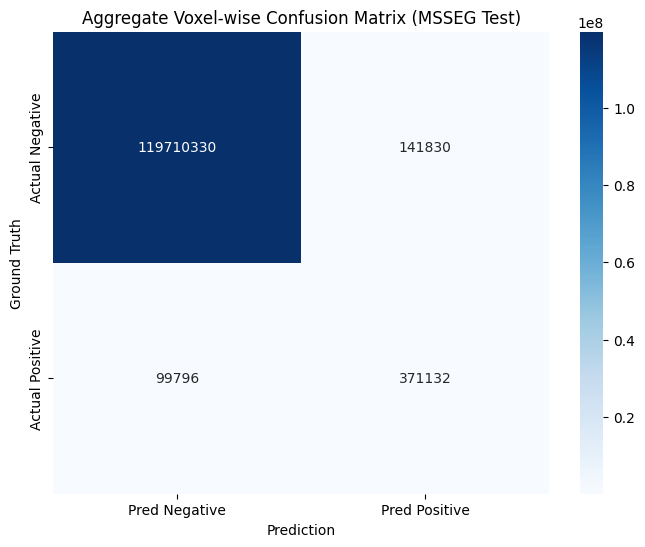

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from monai.metrics import get_confusion_matrix
from tqdm.auto import tqdm
import torch
import numpy as np

# Initialize counters
tp_total, fp_total, fn_total, tn_total = 0, 0, 0, 0

model.eval()
print("Calculating aggregate confusion matrix for 38 cases...")

with torch.no_grad():
    for test_data in tqdm(test_loader):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = sliding_window_inference(inputs, roi_size, sw_batch_size, lambda x: model(x, return_aux=False))

        preds = (torch.sigmoid(logits) > 0.5).float()

        # Compute confusion matrix for this sample
        # get_confusion_matrix returns [Batch, Class, 4] where 4 is TP, FP, TN, FN
        conf_m = get_confusion_matrix(y_pred=preds.cpu(), y=labels.cpu())

        tp_total += conf_m[..., 0].sum().item()
        fp_total += conf_m[..., 1].sum().item()
        tn_total += conf_m[..., 2].sum().item()
        fn_total += conf_m[..., 3].sum().item()

# Construct matrix for plotting: [[TN, FP], [FN, TP]]
cm_array = np.array([[tn_total, fp_total], [fn_total, tp_total]])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_array, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=['Pred Negative', 'Pred Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title("Aggregate Voxel-wise Confusion Matrix (MSSEG Test)")
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.show()

## Test results table

In [19]:
import pandas as pd
import numpy as np
from monai.metrics import DiceMetric, ConfusionMatrixMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
import torch
from tqdm.auto import tqdm

post_pred = AsDiscrete(threshold=0.5)
roi_size = (96, 96, 96)
sw_batch_size = 2

dice_metric = DiceMetric(include_background=False, reduction="none")
conf_matrix = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall"], reduction="none")

model.eval()
results = []

print("Evaluating 38 test cases...")
with torch.no_grad():
    for i, test_data in enumerate(tqdm(test_loader)):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device)
        case_id = test_data.get("case_id", [f"Case_{i}"])[0]

        # Inference
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = sliding_window_inference(inputs, roi_size, sw_batch_size, lambda x: model(x, return_aux=False))

        probs = torch.sigmoid(logits)
        preds = post_pred(probs)

        # Calculate Volumes
        gt_vol = torch.sum(labels).item()
        pred_vol = torch.sum(preds).item()

        # Calculate Metrics
        dice_metric(y_pred=preds, y=labels)
        conf_matrix(y_pred=preds, y=labels)

        dice_val = dice_metric.aggregate().item()

        # Handle Empty Ground Truth cases (NaN handling)
        if gt_vol == 0:
            if pred_vol == 0:
                dice_val = 1.0  # Perfect prediction of empty case
            else:
                dice_val = 0.0  # False positive on empty case
        elif np.isnan(dice_val):
            dice_val = 0.0

        prec_rec = conf_matrix.aggregate()
        precision_val = prec_rec[0].item() if not torch.isnan(prec_rec[0]) else (1.0 if (gt_vol == 0 and pred_vol == 0) else 0.0)
        recall_val = prec_rec[1].item() if not torch.isnan(prec_rec[1]) else (1.0 if (gt_vol == 0 and pred_vol == 0) else 0.0)

        results.append({
            "Patient ID": case_id,
            "Dice": round(float(dice_val), 4),
            "Precision": round(float(precision_val), 4),
            "Recall (Sens)": round(float(recall_val), 4),
            "Ground Truth Volume (mm3)": gt_vol,
            "Pred Volume (mm3)": pred_vol
        })

        # Reset metrics for next case
        dice_metric.reset()
        conf_matrix.reset()

# Create DataFrame
df_results = pd.DataFrame(results)
# Highlight summary
display(df_results)

Evaluating 38 test cases...


  0%|          | 0/38 [00:00<?, ?it/s]

,Patient ID,Dice,Precision,Recall (Sens),Ground Truth Volume (mm3),Pred Volume (mm3)
0,MSSEG_TEST_Center_01_Patient_01,0.2004,0.1159,0.7388,356.0000,2269.0000
1,MSSEG_TEST_Center_01_Patient_02,0.8287,0.7991,0.8606,24458.0000,26340.0000
2,MSSEG_TEST_Center_01_Patient_03,0.8213,0.7973,0.8466,10981.0000,11660.0000
3,MSSEG_TEST_Center_01_Patient_04,0.8510,0.7753,0.9431,34830.0000,42368.0000
4,MSSEG_TEST_Center_01_Patient_05,0.8175,0.8176,0.8174,15743.0000,15738.0000
5,MSSEG_TEST_Center_01_Patient_06,0.7503,0.7953,0.7102,30266.0000,27025.0000
6,MSSEG_TEST_Center_01_Patient_07,0.6678,0.6392,0.6992,4598.0000,5030.0000
7,MSSEG_TEST_Center_01_Patient_08,0.8116,0.8603,0.7682,21421.0000,19127.0000
8,MSSEG_TEST_Center_01_Patient_09,0.3836,0.2614,0.7202,604.0000,1664.0000
9,MSSEG_TEST_Center_01_Patient_10,0.7334,0.7155,0.7522,5166.0000,5431.0000


## centers statistics

In [20]:
import pandas as pd

# 1. Extract Center information from the Patient IDs in the results
def extract_center(patient_id):
    parts = patient_id.split('_')
    if 'Center' in parts:
        idx = parts.index('Center')
        return f"Center_{parts[idx+1]}"
    return "Unknown"

df_results['Center'] = df_results['Patient ID'].apply(extract_center)

# 2. Analyze distribution
test_centers = df_results['Center'].unique()
val_centers = set([extract_center(f['case_id']) for f in val_files])
train_centers = set([extract_center(f['case_id']) for f in train_files])

print(f"Centers in Training: {sorted(list(train_centers))}")
print(f"Centers in Validation: {sorted(list(val_centers))}")
print(f"Centers in Test: {sorted(list(test_centers))}")

# 3. Aggregate results by Center
# Fixed: Changed 'GT Volume (mm3)' to 'Ground Truth Volume (mm3)' to match df_results
center_summary = df_results.groupby('Center').agg({
    'Dice': ['mean', 'std', 'count'],
    'Precision': 'mean',
    'Recall (Sens)': 'mean',
    'Ground Truth Volume (mm3)': 'mean'
}).round(4)

print("\nPerformance Summary per Center/Scanner:")
display(center_summary)

Centers in Training: ['Center_01', 'Center_07', 'Center_08']
Centers in Validation: ['Center_07', 'Center_08']
Centers in Test: ['Center_01', 'Center_03', 'Center_07', 'Center_08']

Performance Summary per Center/Scanner:


Dice              Precision Recall (Sens)  \
            mean    std count      mean          mean   
Center                                                  
Center_01 0.6866 0.2193    10    0.6577        0.7857   
Center_03 0.6009 0.2142     8    0.5868        0.7475   
Center_07 0.5840 0.2552    10    0.4937        0.7625   
Center_08 0.5999 0.2705    10    0.5719        0.8161   

          Ground Truth Volume (mm3)  
                               mean  
Center                               
Center_01                14842.3000  
Center_03                17462.1250  
Center_07                 6241.1000  
Center_08                12039.7000

## Training Curves

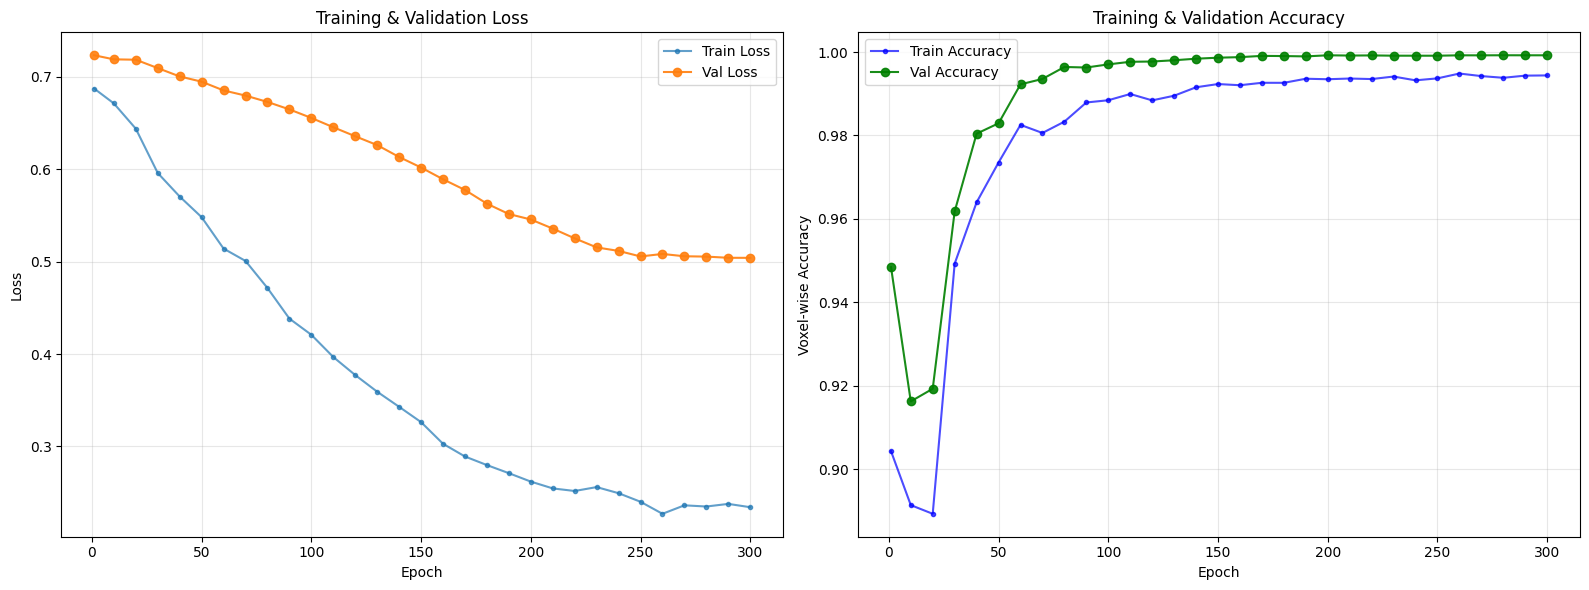

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_csv_path = "/content/training_metrics_log_other_split.csv"

if os.path.exists(log_csv_path):
    df_log = pd.read_csv(log_csv_path)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Subplot 1: Loss
    axes[0].plot(df_log["epoch"], df_log["train_loss"], label="Train Loss", marker='.', alpha=0.7)
    axes[0].plot(df_log["epoch"], df_log["val_loss"], label="Val Loss", marker='o', alpha=0.9)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Subplot 2: Accuracy (Replacing Dice)
    axes[1].plot(df_log["epoch"], df_log["train_acc"], label="Train Accuracy", color="blue", marker='.', alpha=0.7)
    axes[1].plot(df_log["epoch"], df_log["val_acc"], label="Val Accuracy", color="green", marker='o', alpha=0.9)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Voxel-wise Accuracy")
    axes[1].set_title("Training & Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(f"Log file {log_csv_path} not found. Please ensure training has started and logged data.")

## Eval test without preprocessing

Evaluating 38 cases without preprocessing...


  0%|          | 0/38 [00:00<?, ?it/s]

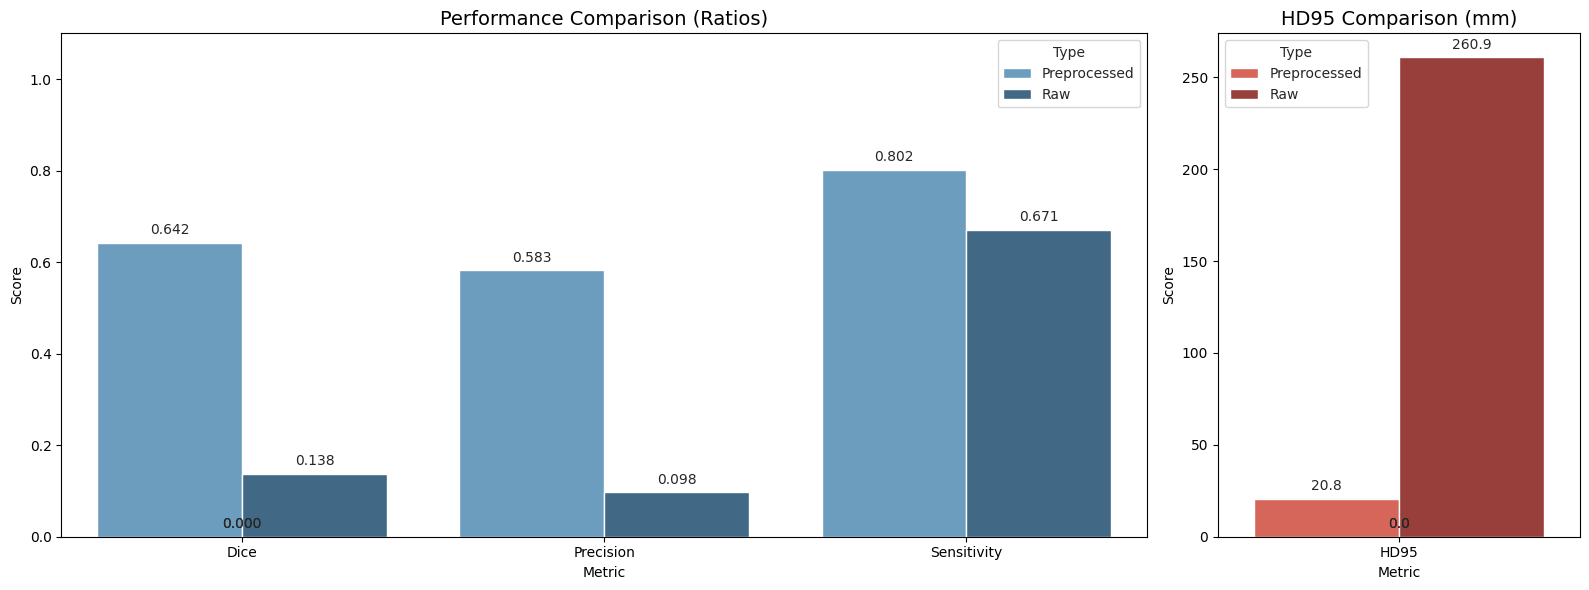


--- RAW DATA EVALUATION SUMMARY ---
Dice: 0.1377
Precision: 0.0977
Sensitivity: 0.6712
HD95: 260.9431


In [22]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ConcatItemsd, EnsureTyped
from monai.data import Dataset, DataLoader
from monai.metrics import DiceMetric, ConfusionMatrixMetric, HausdorffDistanceMetric
from monai.inferers import sliding_window_inference

# 1. Define minimal transforms (No Spacing, No NormalizeIntensity)
raw_test_transforms = Compose([
    LoadImaged(keys=["flair", "t1", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
    EnsureTyped(keys=["image", "label"]),
])

raw_test_ds = Dataset(data=msseg_test_files, transform=raw_test_transforms)
raw_test_loader = DataLoader(raw_test_ds, batch_size=1, num_workers=0)

# 2. Setup Metrics
model.eval()
dice_metric = DiceMetric(include_background=False, reduction="mean")
conf_metric = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall"], reduction="mean")
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean", get_not_nans=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating {len(msseg_test_files)} cases without preprocessing...")

with torch.no_grad():
    for test_data in tqdm(raw_test_loader):
        inputs = test_data["image"].to(device)
        labels = test_data["label"].to(device)
        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits = sliding_window_inference(inputs, (96, 96, 96), 2, lambda x: model(x, return_aux=False), overlap=0.5)
        preds = (torch.sigmoid(logits) > 0.5).float()
        dice_metric(y_pred=preds, y=labels)
        conf_metric(y_pred=preds, y=labels)
        hd95_metric(y_pred=preds.cpu(), y=labels.cpu())

# 3. Aggregate results
raw_res = {"Dice": dice_metric.aggregate().item(), "Precision": conf_metric.aggregate()[0].item(), "Sensitivity": conf_metric.aggregate()[1].item(), "HD95": hd95_metric.aggregate().item()}
dice_metric.reset(); conf_metric.reset(); hd95_metric.reset()

# 4. Visualization
pre_res = {"Dice": summary_stats.loc["Dice", "Mean"], "Precision": summary_stats.loc["Precision", "Mean"], "Sensitivity": summary_stats.loc["Sensitivity", "Mean"], "HD95": summary_stats.loc["HD95 (mm)", "Mean"]}

plot_df = pd.DataFrame([{"Metric": k, "Score": v, "Type": "Preprocessed"} for k, v in pre_res.items()] + [{"Metric": k, "Score": v, "Type": "Raw" } for k, v in raw_res.items()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [3, 1]})
sns.set_style("whitegrid")

# Main Plot (Ratios)
sub_df = plot_df[plot_df['Metric'] != 'HD95']
g1 = sns.barplot(data=sub_df, x="Metric", y="Score", hue="Type", palette="Blues_d", ax=ax1)
ax1.set_title("Performance Comparison (Ratios)", fontsize=14)
ax1.set_ylim(0, 1.1)
for p in g1.patches: g1.annotate(format(p.get_height(), '.3f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

# HD95 Plot
hd_df = plot_df[plot_df['Metric'] == 'HD95']
g2 = sns.barplot(data=hd_df, x="Metric", y="Score", hue="Type", palette="Reds_d", ax=ax2)
ax2.set_title("HD95 Comparison (mm)", fontsize=14)
for p in g2.patches: g2.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

print(f"\n--- RAW DATA EVALUATION SUMMARY ---")
for k, v in raw_res.items(): print(f"{k}: {v:.4f}")

## ablation study  

Ablation: Full:   0%|          | 0/38 [00:00<?, ?it/s]

Ablation: NoGate:   0%|          | 0/38 [00:00<?, ?it/s]

Ablation: NoAtt:   0%|          | 0/38 [00:00<?, ?it/s]

Ablation: Missing-FLAIR:   0%|          | 0/38 [00:00<?, ?it/s]

Ablation: Missing-T1:   0%|          | 0/38 [00:00<?, ?it/s]

Ablation: Missing-T2:   0%|          | 0/38 [00:00<?, ?it/s]

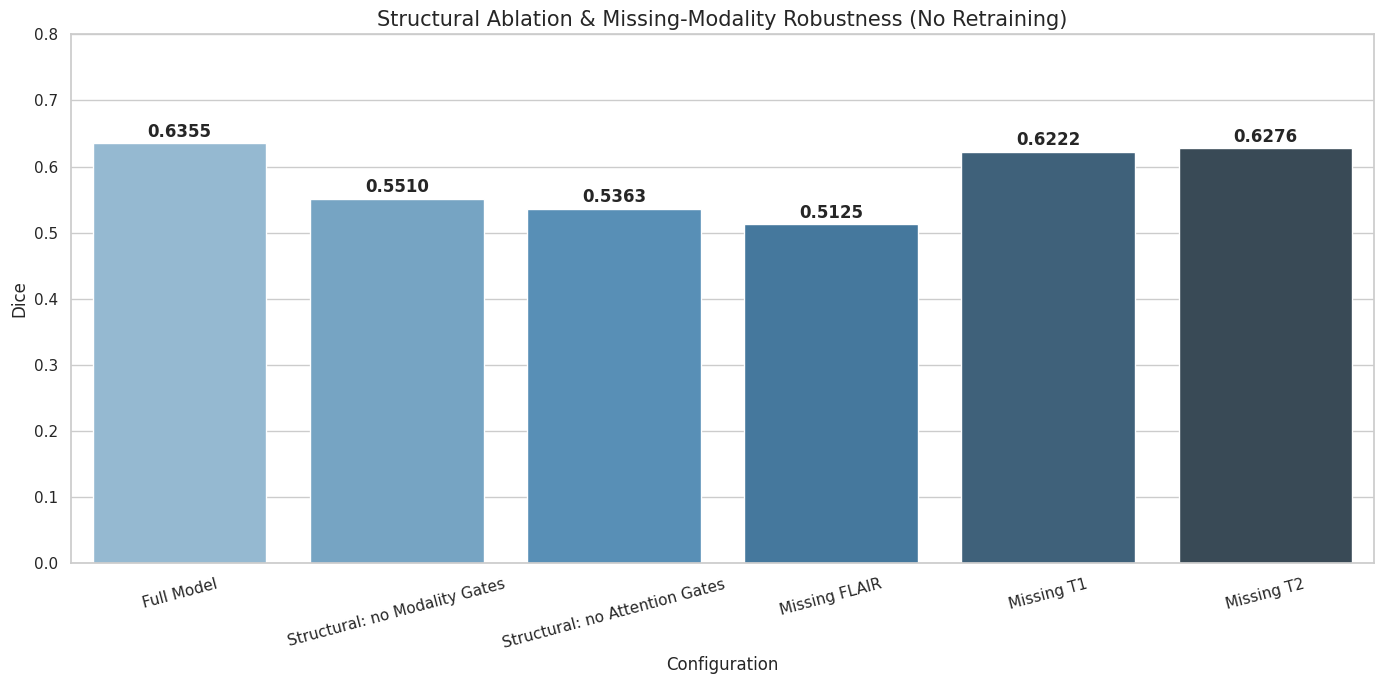

,Configuration,Dice
0,Full Model,0.6355
1,Structural: no Modality Gates,0.5510
2,Structural: no Attention Gates,0.5363
3,Missing FLAIR,0.5125
4,Missing T1,0.6222
5,Missing T2,0.6276


In [26]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from tqdm.auto import tqdm

weight_path = "/content/best_tri_encoder_msseg_only_other_split.pth"


def run_ablation_eval(model_obj, loader, name, drop_modality_idx=None):
    model_obj.eval()
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    with torch.no_grad():
        for data in tqdm(loader, desc=f"Ablation: {name}", leave=False):
            inputs = data["image"].to(device)
            labels = data["label"].to(device)

            if drop_modality_idx is not None:
                inputs = inputs.clone()
                inputs[:, drop_modality_idx:drop_modality_idx + 1] = 0

            with torch.amp.autocast(device_type="cuda"):
                outputs = sliding_window_inference(
                    inputs, (96, 96, 96), 2, lambda x: model_obj(x, return_aux=False)
                )
            preds = (torch.sigmoid(outputs) > 0.5).float()
            dice_metric(y_pred=preds, y=labels)
    return dice_metric.aggregate().item()


ablation_results = []

#  1. Baseline (Full Model)
model_full = TriEncoderAttentionUNet3D().to(device)
model_full.load_state_dict(torch.load(weight_path, map_location=device))
ablation_results.append({
    "Configuration": "Full Model",
    "Dice": run_ablation_eval(model_full, test_loader, "Full")
})

# 2. Structural Ablation: Modality Gates removed (test-time bypass)
class NoGateTriEncoder(TriEncoderAttentionUNet3D):
    def forward(self, x, return_aux=False, return_attention=False):
        flair_in, t1_in, t2_in = x[:, 0:1], x[:, 1:2], x[:, 2:3]
        f1, t1_1, t2_1 = self.flair_l1(flair_in), self.t1_l1(t1_in), self.t2_l1(t2_in)
        fused_skip_l1 = self.fuse_l1(torch.cat([f1, t1_1, t2_1], dim=1))
        f2 = self.flair_level_2(self.pool(f1))
        t1_2 = self.t1_level_2(self.pool(t1_1))
        t2_2 = self.t2_level_2(self.pool(t2_1))
        fused_skip_l2 = self.fuse_level_2(torch.cat([f2, t1_2, t2_2], dim=1))
        fused_f3 = self.joint_l3(self.pool(fused_skip_l2))
        bottle = self.bottleneck(self.pool(fused_f3))
        dec_l3 = self.dec3(torch.cat([self.up3(bottle), fused_f3], dim=1))
        dec_l2 = self.dec2(torch.cat([self.up2(dec_l3), fused_skip_l2], dim=1))
        dec_l1 = self.dec1(torch.cat([self.up1(dec_l2), fused_skip_l1], dim=1))
        return self.final(dec_l1)

model_no_gate = NoGateTriEncoder().to(device)
model_no_gate.load_state_dict(torch.load(weight_path, map_location=device))
ablation_results.append({
    "Configuration": "Structural: no Modality Gates",
    "Dice": run_ablation_eval(model_no_gate, test_loader, "NoGate")
})

# 3. Structural Ablation: Attention Gates removed (test-time bypass)
class NoAttTriEncoder(TriEncoderAttentionUNet3D):
    def forward(self, x, return_aux=False, return_attention=False):
        flair, t1, t2 = x[:, 0:1], x[:, 1:2], x[:, 2:3]
        f1, t1_1, t2_1 = self.flair_l1(flair), self.t1_l1(t1), self.t2_l1(t2)
        [f1g, t11g, t21g], _ = self.modality_gate_l1([f1, t1_1, t2_1])
        skip1 = self.fuse_l1(torch.cat([f1g, t11g, t21g], dim=1))
        f2 = self.flair_level_2(self.pool(f1))
        t1_2 = self.t1_level_2(self.pool(t1_1))
        t2_2 = self.t2_level_2(self.pool(t2_1))
        [f2g, t12g, t22g], _ = self.modality_gate_l2([f2, t1_2, t2_2])
        skip2 = self.fuse_level_2(torch.cat([f2g, t12g, t22g], dim=1))
        f3 = self.joint_l3(self.pool(skip2))
        btl = self.bottleneck(self.pool(f3))
        d3 = self.dec3(torch.cat([self.up3(btl), f3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), skip2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), skip1], dim=1))
        return self.final(d1)

model_no_att = NoAttTriEncoder().to(device)
model_no_att.load_state_dict(torch.load(weight_path, map_location=device))
ablation_results.append({
    "Configuration": "Structural: no Attention Gates",
    "Dice": run_ablation_eval(model_no_att, test_loader, "NoAtt")
})

# 4. Robustness: Missing Modality
for idx, mod_name in enumerate(["FLAIR", "T1", "T2"]):
    d = run_ablation_eval(model_full, test_loader, f"Missing-{mod_name}", drop_modality_idx=idx)
    ablation_results.append({"Configuration": f"Missing {mod_name}", "Dice": d})

#  Plotting
df_ablation = pd.DataFrame(ablation_results)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))
sns.barplot(data=df_ablation, x="Configuration", y="Dice", hue="Configuration",
            palette="Blues_d", legend=False)
plt.title("Structural Ablation & Missing-Modality Robustness (No Retraining)", fontsize=15)
plt.xticks(rotation=15)
plt.ylim(0, 0.8)
for i, v in enumerate(df_ablation["Dice"]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center", weight="bold")
plt.tight_layout()
plt.show()

display(df_ablation)